In [ ]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from sklearn.model_selection import train_test_split
from ISLP import load_data , confusion_table
from ISLP.models import ModelSpec as MS

In [ ]:
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,export_text)
from sklearn.metrics import (accuracy_score, log_loss,mean_squared_error,make_scorer,precision_score)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from sklearn.linear_model import LinearRegression

In [ ]:
from ISLP import load_data
boston=load_data("Boston")
X = boston.drop(columns='medv')
y = boston['medv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=8)



In [ ]:
### Linear Regression ###
lm = LinearRegression()
lm.fit(X_train, y_train)
lm_pred = lm.predict(X_test)
mse_lm = mean_squared_error(y_test, lm_pred)
print(f"Linear Regression MSE: {mse_lm:.4f}")

Linear Regression MSE: 26.7580


In [ ]:
model = MS(boston.columns.drop('medv'), intercept=False)
D = model.fit_transform(boston)
feature_names = list(D.columns)
X = np.asarray(D)

In [ ]:
# Decision Tree Regressor
reg = DTR(max_depth=8)
reg.fit(X_train , y_train)
ax = subplots(figsize=(12,12))[1]
plot_tree(reg,feature_names=feature_names, ax=ax)

In [ ]:
pred_tree_full = reg.predict(X_test)
mse_tree_full = mean_squared_error(y_test, pred_tree_full)
print(f"Decision Tree MSE: {mse_tree_full:.4f}")

Decision Tree MSE: 20.7899


In [ ]:
# Cross-validation pruning
ccp_path = reg.cost_complexity_pruning_path(X_train , y_train)
kfold = skm.KFold(5,shuffle=True,random_state =10)
grid = skm.GridSearchCV(reg ,
{'ccp_alpha': ccp_path.ccp_alphas},
refit=True ,
cv=kfold ,
scoring='neg_mean_squared_error')
G = grid.fit(X_train, y_train)


In [ ]:
# Print the best ccp_alpha found by GridSearchCV
print(f"Best ccp_alpha: {G.best_params_['ccp_alpha']}")

# Print the best score (neg_mean_squared_error)
print(f"Best cross-validation score (neg_mean_squared_error): {G.best_score_}")

# Print all the results from GridSearchCV
results = pd.DataFrame(G.cv_results_)
sorted_results = results.sort_values(by='mean_test_score', ascending=False)
print(sorted_results[['param_ccp_alpha', 'mean_test_score', 'std_test_score']])

Best ccp_alpha: 0.7589403350273332
Best cross-validation score (neg_mean_squared_error): -20.725250265743448
    param_ccp_alpha  mean_test_score  std_test_score
78         0.758940       -20.725250        8.332712
79         0.845750       -20.781873        8.921247
6          0.002846       -20.852916        9.664004
77         0.674928       -20.956996        7.715804
18         0.010455       -21.185598        9.181545
..              ...              ...             ...
82         3.858414       -25.893389       10.694228
83         5.061224       -28.195369       10.287076
84         5.559271       -29.962601       10.829597
85        12.804962       -43.452711       16.247726
86        37.680437       -65.288530       34.707023

[87 rows x 3 columns]


[Text(0.4583333333333333, 0.9166666666666666, 'lstat <= 8.91\nsquared_error = 78.13\nsamples = 253\nvalue = 22.593'),
 Text(0.25, 0.75, 'rm <= 7.452\nsquared_error = 81.285\nsamples = 83\nvalue = 31.378'),
 Text(0.35416666666666663, 0.8333333333333333, 'True  '),
 Text(0.16666666666666666, 0.5833333333333334, 'dis <= 1.485\nsquared_error = 46.679\nsamples = 71\nvalue = 28.81'),
 Text(0.08333333333333333, 0.4166666666666667, 'squared_error = 0.0\nsamples = 3\nvalue = 50.0'),
 Text(0.25, 0.4166666666666667, 'rm <= 6.55\nsquared_error = 28.055\nsamples = 68\nvalue = 27.875'),
 Text(0.16666666666666666, 0.25, 'squared_error = 6.037\nsamples = 28\nvalue = 23.346'),
 Text(0.3333333333333333, 0.25, 'ptratio <= 18.15\nsquared_error = 19.062\nsamples = 40\nvalue = 31.045'),
 Text(0.25, 0.08333333333333333, 'squared_error = 9.51\nsamples = 26\nvalue = 32.885'),
 Text(0.4166666666666667, 0.08333333333333333, 'squared_error = 18.846\nsamples = 14\nvalue = 27.629'),
 Text(0.3333333333333333, 0.5833

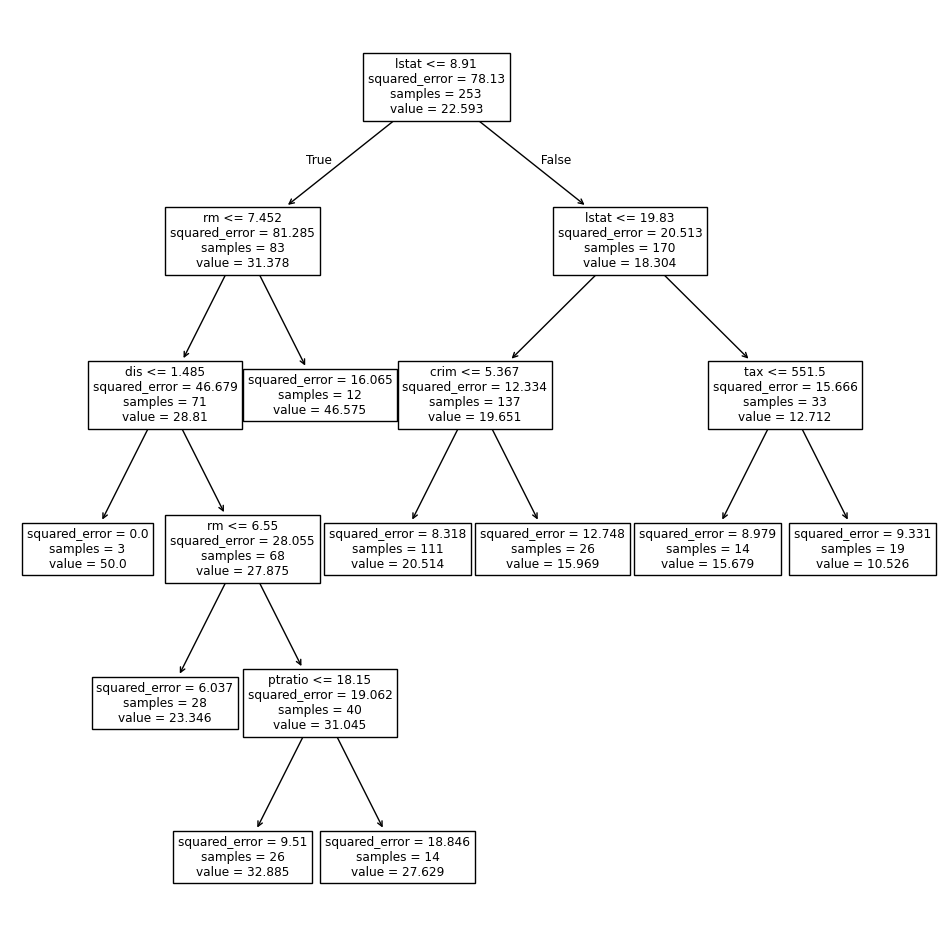

In [ ]:
ax = subplots(figsize=(12,12))[1]
plot_tree(G.best_estimator_ , feature_names=feature_names ,ax=ax)

In [ ]:
best_tree = G.best_estimator_
predictions = best_tree.predict(X_test)

# Calculate MSE on the test set
mse = mean_squared_error(y_test, predictions)
print(f"Test MSE of the pruned tree: {mse}")

Test MSE of the pruned tree: 24.28048839573411


In [ ]:
# Load the Caravan dataset
caravan = load_data("Caravan")

# Prepare features and target
X_caravan = caravan.drop(columns='Purchase')
y_caravan = caravan['Purchase']

# Train-Test split using train_test_split
X_train_caravan, X_test_caravan, y_train_caravan, y_test_caravan = train_test_split(
    X_caravan, y_caravan, test_size=0.5, random_state=8)


In [ ]:
model = MS(caravan.columns.drop('Purchase'), intercept=False)
D = model.fit_transform(caravan)
feature_names = list(D.columns)
X = np.asarray(D)

In [ ]:
clf = DTC(criterion='entropy') ##could use 'gini'
clf.fit(X_train_caravan, y_train_caravan)
pred_tree_caravan = clf.predict(X_test_caravan)
test_accuracy =accuracy_score(y_test_caravan, pred_tree_caravan)
print(f"Test set accuracy of the pruned tree: {test_accuracy:.4f}")
confusion = confusion_table(pred_tree_caravan,y_test_caravan)
confusion

Test set accuracy of the pruned tree: 0.8942


Truth,No,Yes
Predicted,,
No,2587,153
Yes,155,16


[Text(0.47398944643568297, 0.9827586206896551, 'PPERSAUT <= 5.5\nentropy = 0.333\nsamples = 2911\nvalue = [2732, 179]'),
 Text(0.27041019514137793, 0.9482758620689655, 'AWAOREG <= 0.5\nentropy = 0.156\nsamples = 1718\nvalue = [1679, 39]'),
 Text(0.3721998207885304, 0.9655172413793103, 'True  '),
 Text(0.22062923138191956, 0.9137931034482759, 'MINKM30 <= 2.5\nentropy = 0.147\nsamples = 1713\nvalue = [1677, 36]'),
 Text(0.1401831939466348, 0.8793103448275862, 'ABROM <= 0.5\nentropy = 0.207\nsamples = 858\nvalue = [830, 28]'),
 Text(0.13381123058542413, 0.8448275862068966, 'MOPLMIDD <= 1.5\nentropy = 0.228\nsamples = 760\nvalue = [732.0, 28.0]'),
 Text(0.12743926722421345, 0.8103448275862069, 'entropy = 0.0\nsamples = 83\nvalue = [83, 0]'),
 Text(0.1401831939466348, 0.8103448275862069, 'MFGEKIND <= 2.5\nentropy = 0.248\nsamples = 677\nvalue = [649, 28]'),
 Text(0.09239346873755476, 0.7758620689655172, 'MBERARBO <= 0.5\nentropy = 0.366\nsamples = 200\nvalue = [186.0, 14.0]'),
 Text(0.07009

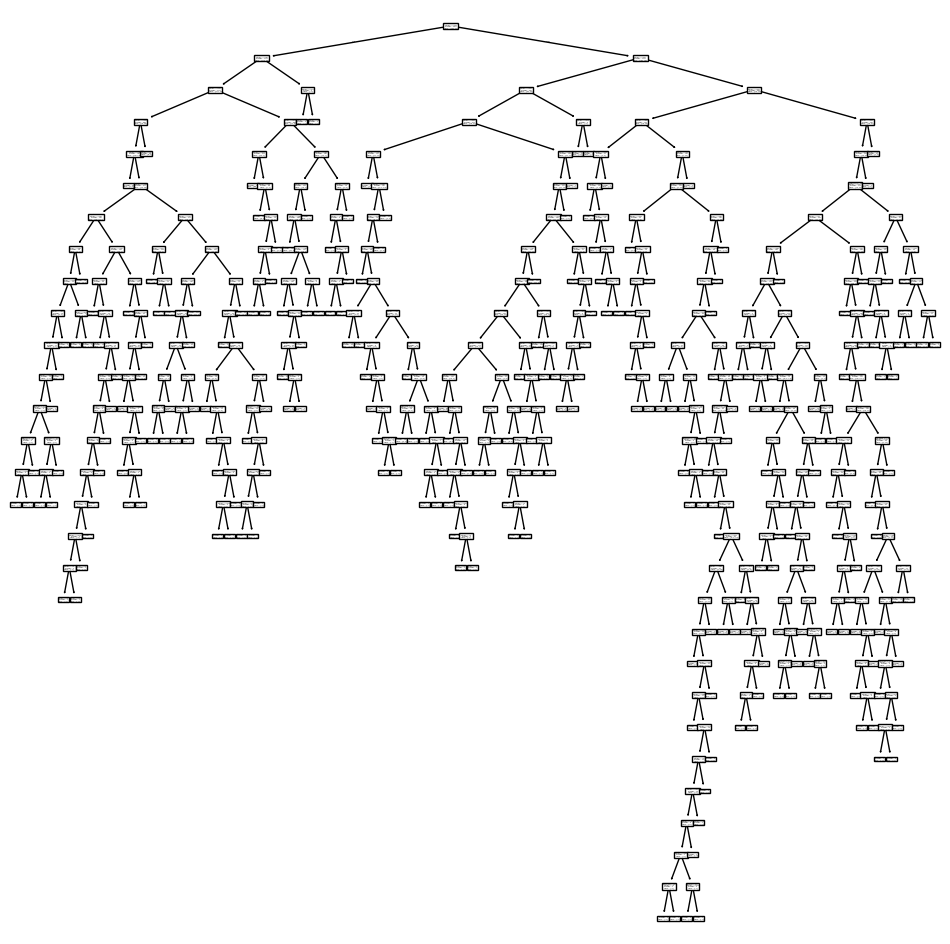

In [ ]:
ax = subplots(figsize=(12, 12))[1]
plot_tree(clf, feature_names=feature_names , ax=ax)

In [ ]:
ccp_path = clf.cost_complexity_pruning_path(X_train_caravan, y_train_caravan)
kfold = skm.KFold(10, random_state=1,shuffle=True)
precision_scorer = make_scorer(precision_score, pos_label='Yes')
grid = skm.GridSearchCV(clf ,
{'ccp_alpha': ccp_path.ccp_alphas},
refit=True ,cv=kfold ,
scoring=precision_scorer) #accuracy, precision, roc_auc, somethingelse:precision_scorer
G=grid.fit(X_train_caravan, y_train_caravan)


In [ ]:
# Best ccp_alpha found by GridSearchCV
print(f"Best ccp_alpha: {G.best_params_['ccp_alpha']}")

# Best accuracy score from cross-validation
print(f"Best cross-validation accuracy: {G.best_score_:.4f}")

# Sort the results by accuracy to view the best pruning levels
results = pd.DataFrame(G.cv_results_)
sorted_results = results.sort_values(by='mean_test_score', ascending=False)
print(sorted_results[['param_ccp_alpha', 'mean_test_score', 'std_test_score']])


In [ ]:
best_tree = G.best_estimator_

# Make predictions with the best tree
predictions = best_tree.predict(X_test_caravan)

test_accuracy = accuracy_score(y_test_caravan, predictions)
print(f"Test set accuracy of the pruned tree: {test_accuracy:.4f}")

confusion = confusion_table(predictions,y_test_caravan)
confusion

Test set accuracy of the pruned tree: 0.9358


Truth,No,Yes
Predicted,,
No,2722,167
Yes,20,2


[Text(0.4, 0.8333333333333334, 'PPERSAUT <= 5.5\nentropy = 0.333\nsamples = 2911\nvalue = [2732, 179]'),
 Text(0.2, 0.5, 'entropy = 0.156\nsamples = 1718\nvalue = [1679, 39]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'PBRAND <= 2.5\nentropy = 0.522\nsamples = 1193\nvalue = [1053, 140]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'entropy = 0.327\nsamples = 585\nvalue = [550, 35]'),
 Text(0.8, 0.16666666666666666, 'entropy = 0.664\nsamples = 608\nvalue = [503, 105]')]

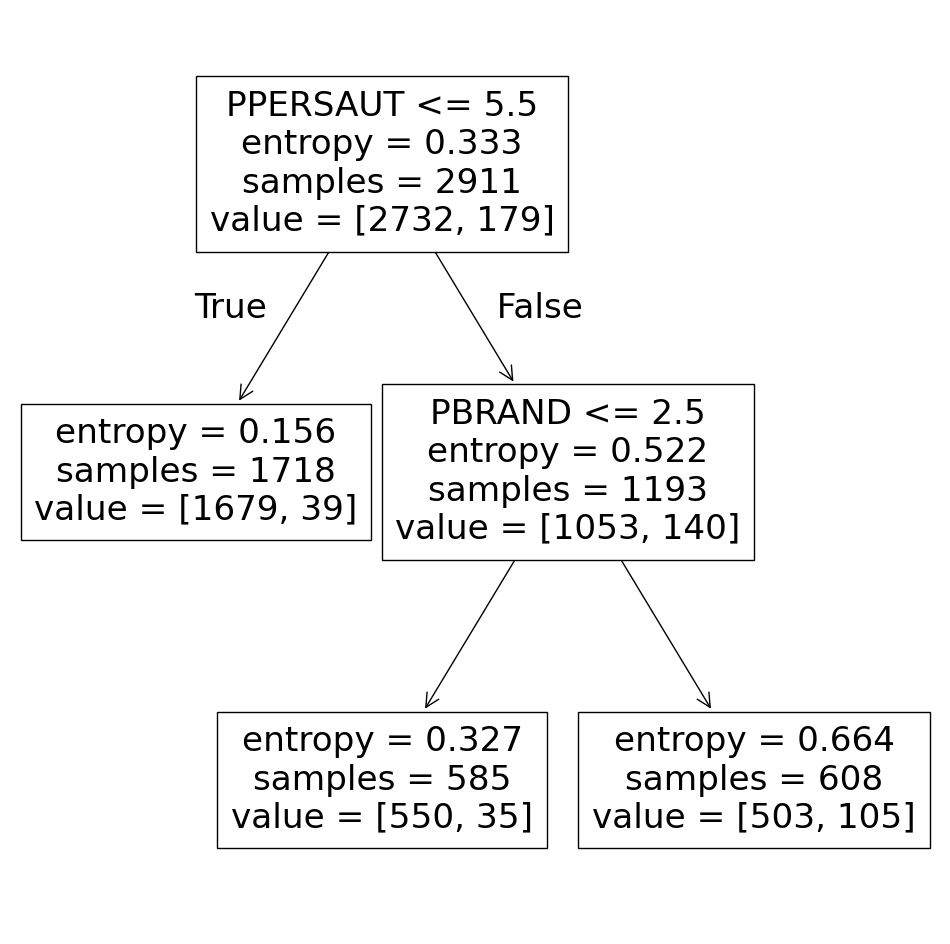

In [ ]:
ax = subplots(figsize=(12, 12))[1]
best_ = G.best_estimator_
plot_tree(best_ , feature_names=feature_names , ax=ax)